<a href="https://colab.research.google.com/github/ssoosso/Image-Processing/blob/main/Lab6_MorphologyProcessing_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Morphological Operations (AI342)
**Student Name:** [Sarah Alsarraf] |
---
### Instructions:
* Do **NOT** add or delete any cells.
* Task 1 is provided as a reference. Complete the missing parts in other tasks.
* Pay attention to the variable names and the requested Structuring Elements.

## Task 1: Basic Operations & Area Analysis
In this section, we apply **Erosion**, **Dialation**, **Opening** and **Closing** and analyze the resulting object areas. Also, we compare a custom **Square Structuring Element** and a **Disk Structuring Element**.
.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 61.9 kB/s eta 0:00:0000:0100:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.6/317.6 kB 73.6 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 74.3 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.0/244.0 kB 72.1 kB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


/var/folders/vd/0132s3hx5yddwj5whclv0j_r0000gn/T/ipykernel_36902/2209906897.py:21: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  open_res = morphology.binary_opening(img, se_disk)
/var/folders/vd/0132s3hx5yddwj5whclv0j_r0000gn/T/ipykernel_36902/2209906897.py:22: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  close_res = morphology.binary_closing(img, se_disk)


Original Area: 1600 pixels
Erosion Area: 1296 pixels
Dilation Area: 1936 pixels
Opening Area: 1580 pixels
Closing Area: 1600 pixels


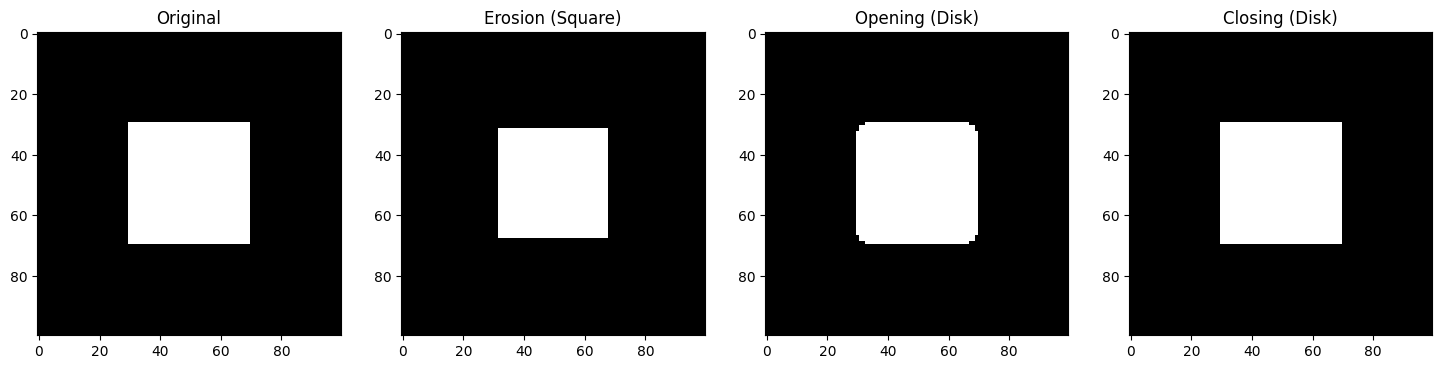

In [ ]:
# Install skimage if not already installed
%pip install scikit-image

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, binary_erosion
from skimage import morphology, data

# Setup Image
img = np.zeros((100, 100), dtype=bool)
img[30:70, 30:70] = True

# 1. Custom Square Structuring Element
se_square = np.ones((5,5), bool)
# 2. Disk Structuring Element
se_disk = morphology.disk(3)

# Applying Operations
ero_res = binary_erosion(img, structure=se_square)
dil_res = binary_dilation(img, structure=se_square)
open_res = morphology.binary_opening(img, se_disk)
close_res = morphology.binary_closing(img, se_disk)

# Area Comparison
print(f"Original Area: {np.sum(img)} pixels")
print(f"Erosion Area: {np.sum(ero_res)} pixels")
print(f"Dilation Area: {np.sum(dil_res)} pixels")
print(f"Opening Area: {np.sum(open_res)} pixels")
print(f"Closing Area: {np.sum(close_res)} pixels")

# Visualization
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img, cmap='gray'); axes[0].set_title("Original")
axes[1].imshow(ero_res, cmap='gray'); axes[1].set_title("Erosion (Square)")
axes[2].imshow(open_res, cmap='gray'); axes[2].set_title("Opening (Disk)")
axes[3].imshow(close_res, cmap='gray'); axes[3].set_title("Closing (Disk)")
plt.show()

---
**Q1: Based on the printed area values, why did the area decrease in Erosion/Opening and increase in Dilation/Closing?**
*Answer:* Erosoin decreases area bc it shrinks the object by removing pixles from edges.
opening also decreases the area bc erosion shrinks the object first and even after dilation tries to grow it back, noise get removed permamntly.
Dilation increases area bc it grows the object by adding pixles to the edges.
Closing increases area bc dilation grows the object first and even after erosion shrinks it back, the filled areas remain

## Task 2: Boundary Extraction
**Formula:** $Boundary = A \oplus (A \ominus B)$
**Note:** Use **Logical XOR** (`^` or `np.logical_xor`) instead of set difference.

**Requirement:** Apply boundary extraction using two different Disk sizes: `disk(1)` and `disk(3)`.

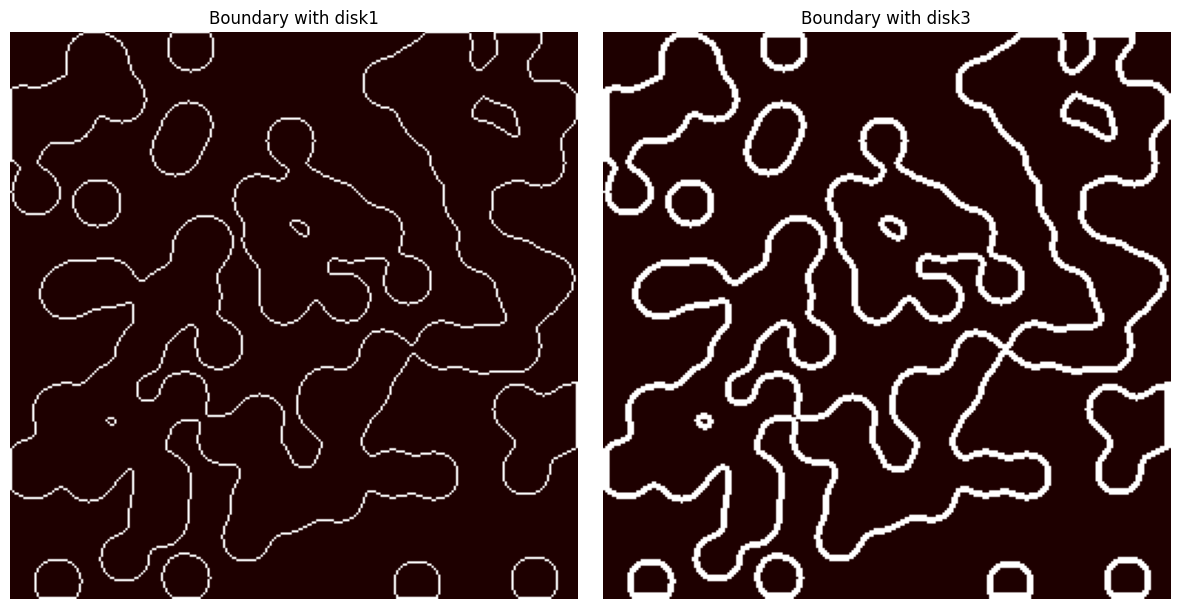

In [ ]:
# TODO: Implement Boundary Extraction
# Use 'binary_img' (Blobs) for this task
rng = np.random.default_rng(seed=42)
binary_img = data.binary_blobs(length=256, blob_size_fraction=0.1, rng=rng)

# 1. Extract boundary using morphology.disk(1)
boundary_disk1 = np.logical_xor(binary_img, binary_erosion(binary_img, structure=morphology.disk(1)))
# 2. Extract boundary using morphology.disk(3)
boundary_disk3 = np.logical_xor(binary_img, binary_erosion(binary_img, structure=morphology.disk(3)))
# 3. Display the results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(boundary_disk1, cmap='pink')
axes[0].set_title("Boundary with disk1")
axes[0].axis('off')

axes[1].imshow(boundary_disk3, cmap='pink')
axes[1].set_title("Boundary with disk3")
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
**Q2: Compare the boundaries extracted using disk(1) and disk(3). What is the effect of SE size on the boundary?**
*Answer:boundary with disk1 thinner and shows more precise edges of the blobs
boundary with disk3 is thicker and shows wider edge regions around blobs


# Task 3: Controlled Thinning & Thickening
**Mathematical Note:**

Since the library does not provide a direct thick function, we use the Duality Principle:
Thickening an image $A$ is equivalent to thinning the complement of $A$ ($A^c$), then complementing the result:$$\text{Thickening}(A) = \text{Thinning}(A^c)^c$$

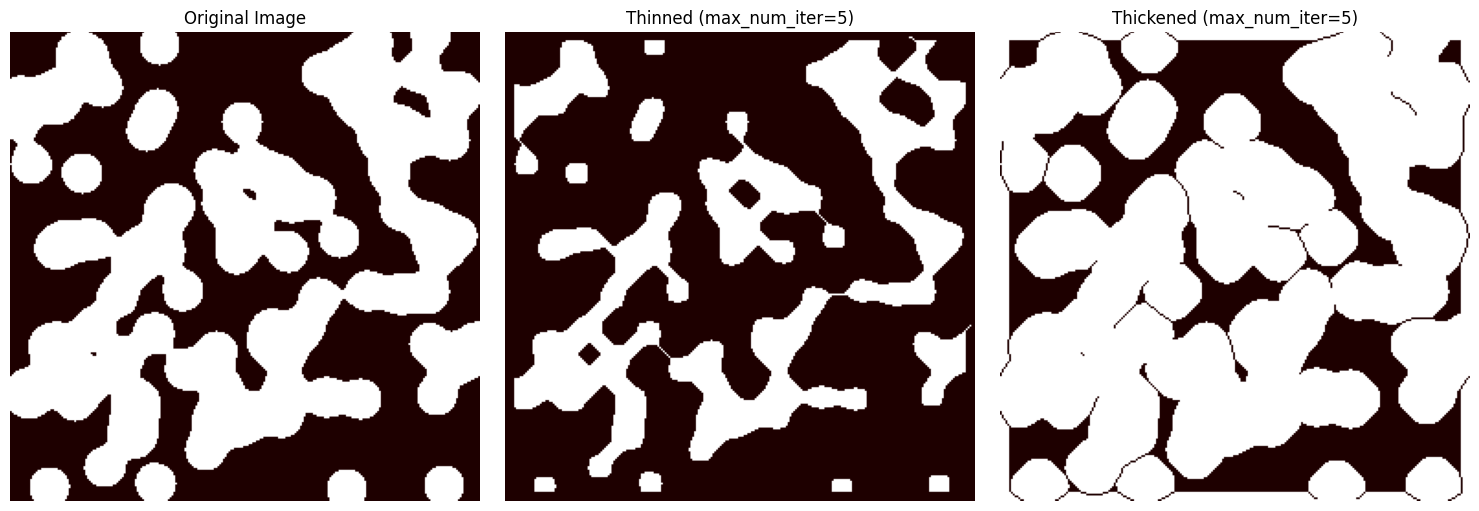

In [ ]:
# --- STUDENT CODE HERE ---
# [Your Code Starts]
# 1. Apply Thinning with max_num_iter = 5
thinned = morphology.thin(binary_img, max_num_iter=5)
# 2. Apply Thickening with max_num_iter = 5
# Note: Use the duality principle for thickening: ~thin(~image)
thickened = ~morphology.thin(~binary_img, max_num_iter=5)
# 3. Display the Original, Thinned, and Thickened images side-by-side.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(binary_img, cmap='pink')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(thinned, cmap='pink')
axes[1].set_title("Thinned (max_num_iter=5)")
axes[1].axis('off')

axes[2].imshow(thickened, cmap='pink')
axes[2].set_title("Thickened (max_num_iter=5)")
axes[2].axis('off')

plt.tight_layout()
plt.show()



# [Your Code Ends]

---
**Q3: How does Thinning differ from Erosion in terms of shape preservation?**
*Answer:*Erosion shrinks the object from all sides, which remove thin structures and changes shape
Thinning maintain the shape and connection between objects much bette. it removes pixles from edges but keeping structue

## Task 4: Hit-or-Miss End-Point Detection
**Objective:** Detect all ridge endings using a rotating Structuring Element.
**Formula:** $A \circledast B = (A \ominus B_1) \cap (A^c \ominus B_2)$

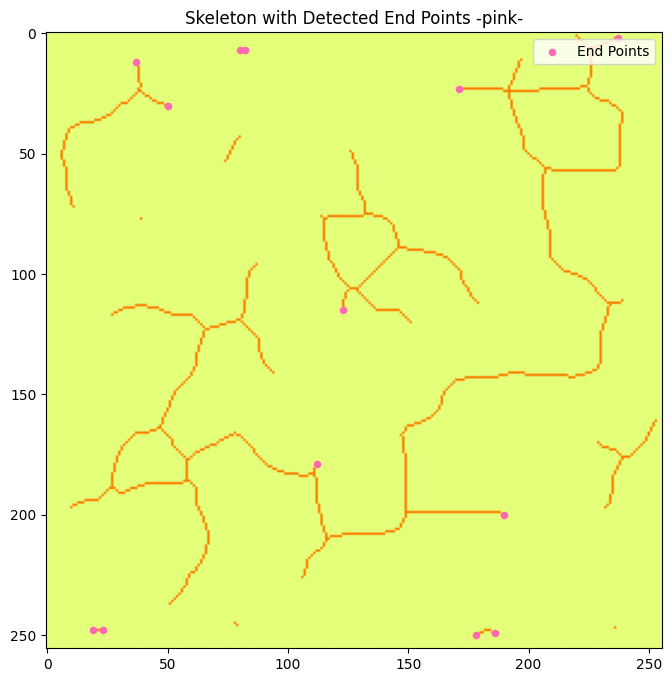

In [ ]:
from scipy.ndimage import binary_hit_or_miss
from skimage.morphology import skeletonize

# Prepare Skeleton
skeleton = skeletonize(binary_img)

# Define the Base Structuring Element (End-point pattern)
se_base = np.array([[0, 0, 0],
                    [0, 1, 0],
                    [0, 1, 0]], dtype=bool)

# --- CODE STRUCTURE (Complete the missing parts) ---
all_end_points = np.zeros_like(skeleton, dtype=bool)

# Loop to detect endings in all 4 directions

for i in range(4):
    # TODO: Rotate the 'se_base' by 90 degrees 'i' times
    # use np.rot90(m, k) where m is SE
    # and k: The number of times the array is rotated by 90 degrees.
    se_rotated = np.rot90(se_base, k=i)# Fill here

    # TODO: Apply binary_hit_or_miss
    detected = binary_hit_or_miss(skeleton, structure1=se_rotated) # Fill here

    # Combine results
    all_end_points |= detected

# Visualization (Final Result Overlay)
plt.figure(figsize=(8, 8))
plt.imshow(skeleton, cmap='Wistia')
y, x = np.where(all_end_points)
plt.scatter(x, y, color='hotpink', s=20, label='End Points')
plt.title("Skeleton with Detected End Points -pink-")
plt.legend()
plt.show()

---
**Q4: In the Hit-or-Miss logic, what does the '1' and '0' in our Structuring Element represent?**
*Answer:*1= must be foreground part of the object/skeleton
0=must be background not part of the object